In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/apple_stock_2015_2026.csv")
print(df.head(10))

        Price               Close                High                 Low  \
0      Ticker                AAPL                AAPL                AAPL   
1        Date                 NaN                 NaN                 NaN   
2  2015-01-02   24.17176055908203  24.638260409797738  23.734001789774272   
3  2015-01-05  23.490802764892578   24.02141888235011   23.30508805151262   
4  2015-01-06  23.493011474609375  23.751686233274114  23.132633885246175   
5  2015-01-07  23.822433471679688  23.921923238379996  23.590288433669837   
6  2015-01-08  24.737741470336914  24.795225299659375  24.032464357853957   
7  2015-01-09  24.764284133911133  25.038435181479937  24.366321575519045   
8  2015-01-12  24.154075622558594  24.901359002541184   24.05458582559967   
9  2015-01-13  24.368528366088867   24.93894069695725  24.078901144962483   

                 Open     Volume  
0                AAPL       AAPL  
1                 NaN        NaN  
2  24.627205239450436  212818400  
3   23.94182

In [2]:
import pandas as pd

df = pd.read_csv(
    "../data/raw/apple_stock_2015_2026.csv",
    skiprows=[1, 2],
    index_col=0,
    parse_dates=True
)
df.index.name = "Date"

print(df.head())
print(df.dtypes)

                Close       High        Low       Open     Volume
Date                                                             
2015-01-02  24.171761  24.638260  23.734002  24.627205  212818400
2015-01-05  23.490803  24.021419  23.305088  23.941826  257142000
2015-01-06  23.493011  23.751686  23.132634  23.554916  263188400
2015-01-07  23.822433  23.921923  23.590288  23.700833  160423600
2015-01-08  24.737741  24.795225  24.032464  24.149643  237458000
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object


In [3]:
print("Shape:", df.shape)
print()
df.info()
print()
print("Missing values:")
print(df.isnull().sum())
print()
print("Duplicate dates:", df.index.duplicated().sum())
print("Date range:", df.index.min(), "to", df.index.max())
print("Sorted oldest to newest:", df.index.is_monotonic_increasing)

Shape: (2953, 5)

<class 'pandas.DataFrame'>
DatetimeIndex: 2953 entries, 2015-01-02 to 2026-09-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2953 non-null   float64
 1   High    2953 non-null   float64
 2   Low     2953 non-null   float64
 3   Open    2953 non-null   float64
 4   Volume  2953 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 138.4 KB

Missing values:
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Duplicate dates: 0
Date range: 2015-01-02 00:00:00 to 2026-09-30 00:00:00
Sorted oldest to newest: True


In [4]:
print(df.describe())
print()
print("Rows where High < Low:", (df["High"] < df["Low"]).sum())
print("Rows where Volume == 0:", (df["Volume"] == 0).sum())
print("Rows with a price <= 0:", (df[["Open", "High", "Low", "Close"]] <= 0).any(axis=1).sum())

             Close         High          Low         Open        Volume
count  2953.000000  2953.000000  2953.000000  2953.000000  2.953000e+03
mean    117.642416   118.820545   116.350285   117.529320  1.074670e+08
std      84.796274    85.634369    83.866664    84.690485  6.780047e+07
min      20.548141    20.850658    20.350258    20.470811  1.791060e+07
25%      37.912342    38.237811    37.318897    37.978637  5.937500e+07
50%     116.661537   117.808792   115.108907   116.364381  9.025720e+07
75%     176.944626   178.274792   174.943867   176.917041  1.337872e+08
max     341.070007   345.339996   338.750000   341.079987  6.488252e+08

Rows where High < Low: 0
Rows where Volume == 0: 0
Rows with a price <= 0: 0


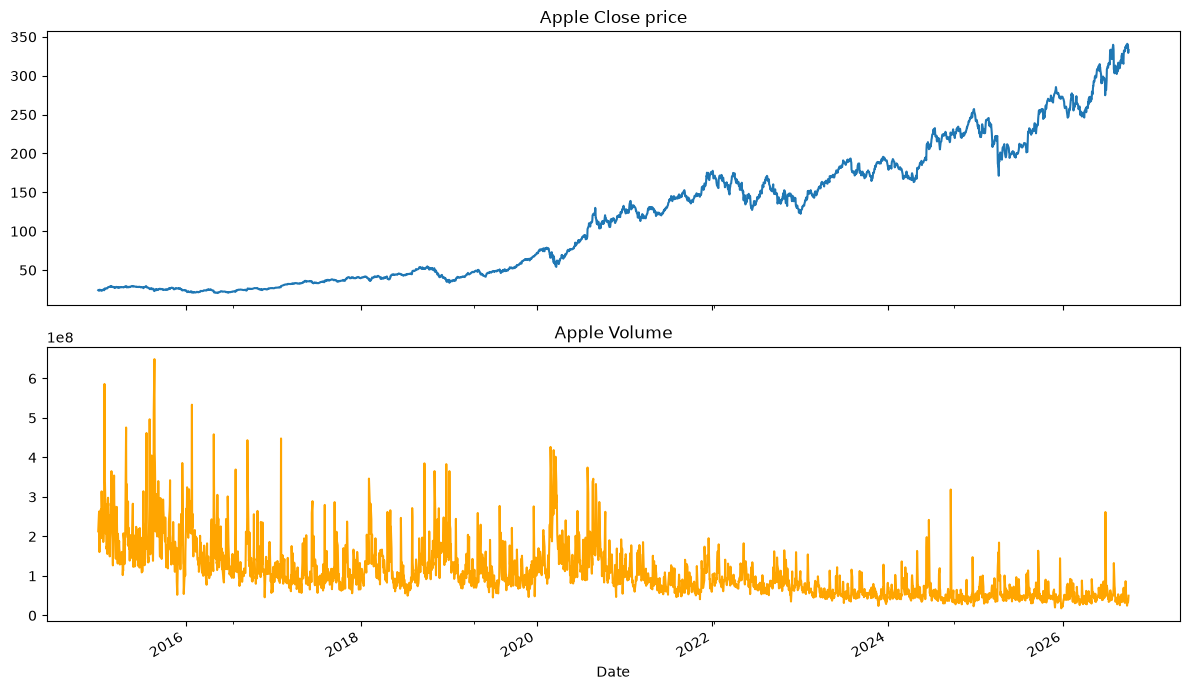

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
df["Close"].plot(ax=ax[0], title="Apple Close price")
df["Volume"].plot(ax=ax[1], title="Apple Volume", color="orange")
plt.tight_layout()
plt.show()

In [6]:
split_idx = int(len(df) * 0.8)   # 80% of the rows

train = df.iloc[:split_idx]
test = df.iloc[split_idx:]

print("Train:", train.shape, "|", train.index.min().date(), "to", train.index.max().date())
print("Test: ", test.shape, "|", test.index.min().date(), "to", test.index.max().date())
print()
print("Max Close in train:", round(train["Close"].max(), 2))
print("Max Close in test: ", round(test["Close"].max(), 2))

Train: (2362, 5) | 2015-01-02 to 2024-05-21
Test:  (591, 5) | 2024-05-22 to 2026-09-30

Max Close in train: 195.72
Max Close in test:  341.07


In [7]:
from sklearn.preprocessing import MinMaxScaler

features = ["Open", "High", "Low", "Close", "Volume"]

scaler = MinMaxScaler()
scaler.fit(train[features])                      # learn min/max from TRAIN only

train_scaled = pd.DataFrame(scaler.transform(train[features]),
                            index=train.index, columns=features)
test_scaled = pd.DataFrame(scaler.transform(test[features]),
                           index=test.index, columns=features)

print("TRAIN scaled (min and max):")
print(train_scaled.agg(["min", "max"]))
print()
print("TEST scaled (min and max):")
print(test_scaled.agg(["min", "max"]))

TRAIN scaled (min and max):
     Open  High  Low  Close  Volume
min   0.0   0.0  0.0    0.0     0.0
max   1.0   1.0  1.0    1.0     1.0

TEST scaled (min and max):
         Open      High       Low     Close    Volume
min  0.858783  0.952172  0.848221  0.860952 -0.009824
max  1.830336  1.839874  1.826976  1.829717  0.471579


In [ ]:
import os
import joblib

os.makedirs("../data/processed", exist_ok=True)

train_scaled.to_csv("../data/processed/train_scaled.csv")
test_scaled.to_csv("../data/processed/test_scaled.csv")
joblib.dump(scaler, "../data/processed/scaler.pkl")

print(os.listdir("../data/processed"))

['scaler.pkl', 'test_scaled.csv', 'train_scaled.csv']


In [10]:
import numpy as np

WINDOW = 60
close_idx = features.index("Close")      # position of Close column (3)

def make_sequences(data, window, target_col):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i - window:i])     # the 60 days before day i
        y.append(data[i, target_col])    # Close of day i
    return np.array(X), np.array(y)

train_arr = train_scaled.values          # DataFrame -> plain numbers
X_train, y_train = make_sequences(train_arr, WINDOW, close_idx)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (2302, 60, 5)
y_train shape: (2302,)


In [11]:
test_arr = test_scaled.values

combined = np.vstack([train_arr[-WINDOW:], test_arr])   # last 60 train days + all test days
X_test, y_test = make_sequences(combined, WINDOW, close_idx)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

# Verification: the first answer should be the first test day's scaled Close
print("First y matches first test Close:", np.isclose(y_test[0], test_scaled["Close"].iloc[0]))

X_test shape: (591, 60, 5)
y_test shape: (591,)
First y matches first test Close: True


In [12]:
np.savez("../data/processed/sequences.npz",
         X_train=X_train, y_train=y_train,
         X_test=X_test, y_test=y_test)

# Verification: load it back and check shapes
data = np.load("../data/processed/sequences.npz")
for name in data.files:
    print(name, data[name].shape)

X_train (2302, 60, 5)
y_train (2302,)
X_test (591, 60, 5)
y_test (591,)


In [13]:
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

print("X_train_flat:", X_train_flat.shape)
print("X_test_flat: ", X_test_flat.shape)

X_train_flat: (2302, 300)
X_test_flat:  (591, 300)
